In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

In [226]:
df = pd.read_csv("C:\\Users\\Acer\\Downloads\\Busy-Buffet\\busy_buffet_clean.csv")

# แปลงวันที่และเวลา
datetime_cols = ["date", "queue_start_dt", "queue_end_dt", "meal_start_dt", "meal_end_dt"]
for col in datetime_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df.shape

(364, 21)

In [227]:
df.head()

,service_no,party_size,queue_start,queue_end,table_no,meal_start,meal_end,guest_type,date,queue_start_dt,queue_end_dt,meal_start_dt,meal_end_dt,wait_min,meal_min,had_queue,had_meal,is_walkaway,day_name,is_weekend,price
0,1,1.0,NaN,NaN,6,06:42:00,07:00:00,In-House,2026-03-13,NaT,NaT,2026-03-13 06:42:00,2026-03-13 07:00:00,NaN,18.0,False,True,False,Friday,False,159
1,2,2.0,NaN,NaN,2,06:44:00,07:10:00,Walk-In,2026-03-13,NaT,NaT,2026-03-13 06:44:00,2026-03-13 07:10:00,NaN,26.0,False,True,False,Friday,False,159
2,3,2.0,NaN,NaN,7A,07:05:00,08:08:00,Walk-In,2026-03-13,NaT,NaT,2026-03-13 07:05:00,2026-03-13 08:08:00,NaN,63.0,False,True,False,Friday,False,159
3,4,1.0,NaN,NaN,8A,07:20:00,08:18:00,In-House,2026-03-13,NaT,NaT,2026-03-13 07:20:00,2026-03-13 08:18:00,NaN,58.0,False,True,False,Friday,False,159
4,5,1.0,NaN,NaN,10A,07:25:00,07:45:00,In-House,2026-03-13,NaT,NaT,2026-03-13 07:25:00,2026-03-13 07:45:00,NaN,20.0,False,True,False,Friday,False,159


In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   service_no      364 non-null    int64         
 1   party_size      363 non-null    float64       
 2   queue_start     73 non-null     object        
 3   queue_end       73 non-null     object        
 4   table_no        349 non-null    object        
 5   meal_start      349 non-null    object        
 6   meal_end        349 non-null    object        
 7   guest_type      364 non-null    object        
 8   date            364 non-null    datetime64[ns]
 9   queue_start_dt  73 non-null     datetime64[ns]
 10  queue_end_dt    73 non-null     datetime64[ns]
 11  meal_start_dt   349 non-null    datetime64[ns]
 12  meal_end_dt     349 non-null    datetime64[ns]
 13  wait_min        73 non-null     float64       
 14  meal_min        348 non-null    float64       
 15  had_qu

In [229]:
df.isna().sum().sort_values(ascending=False)

queue_end_dt      291
queue_start       291
queue_end         291
queue_start_dt    291
wait_min          291
meal_min           16
table_no           15
meal_start         15
meal_end           15
meal_start_dt      15
meal_end_dt        15
party_size          1
had_meal            0
is_weekend          0
day_name            0
is_walkaway         0
service_no          0
had_queue           0
date                0
guest_type          0
price               0
dtype: int64

In [230]:
df[["date", "service_no"]].duplicated().sum()

0

In [231]:
df["meal_hour"] = df["meal_start_dt"].dt.hour
df["walkaway_label"] = df["is_walkaway"].map({True: "Walkaway", False: "Stayed"})
df["day_type"] = df["is_weekend"].map({True: "Weekend", False: "Weekday"})

In [232]:
df.loc[df["had_queue"] == False, "wait_min"] = 0

In [233]:
df.describe(include="all")

,service_no,party_size,queue_start,queue_end,table_no,meal_start,meal_end,guest_type,date,queue_start_dt,queue_end_dt,meal_start_dt,meal_end_dt,wait_min,meal_min,had_queue,had_meal,is_walkaway,day_name,is_weekend,price,meal_hour,walkaway_label,day_type
count,364.000000,363.000000,73,73,349,349,349,364,364,73,73,349,349,364.000000,348.000000,364,364,364,364,364,364.000000,349.000000,364,364
unique,NaN,NaN,54,55,49,202,187,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,5,2,NaN,NaN,2,2
top,NaN,NaN,09:10:00,09:25:00,16,08:43:00,09:30:00,Walk-In,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,Sunday,False,NaN,NaN,Stayed,Weekday
freq,NaN,NaN,6,4,24,6,7,207,NaN,NaN,NaN,NaN,NaN,NaN,NaN,291,349,350,86,197,NaN,NaN,350,197
mean,37.596154,1.823691,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-15 10:13:11.208791040,2026-03-15 03:11:42.739725824,2026-03-15 03:46:33.698630144,2026-03-15 19:38:16.160458240,2026-03-15 20:39:15.128940288,6.989011,61.229885,NaN,NaN,NaN,NaN,NaN,177.351648,8.567335,NaN,NaN
min,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-13 00:00:00,2026-03-14 07:07:00,2026-03-14 07:15:00,2026-03-13 06:42:00,2026-03-13 07:00:00,0.000000,10.000000,NaN,NaN,NaN,NaN,NaN,159.000000,2.000000,NaN,NaN
25%,19.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-14 00:00:00,2026-03-14 09:40:00,2026-03-14 09:54:00,2026-03-14 08:17:00,2026-03-14 09:26:00,0.000000,35.000000,NaN,NaN,NaN,NaN,NaN,159.000000,7.000000,NaN,NaN
50%,37.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-15 00:00:00,2026-03-15 08:58:00,2026-03-15 09:33:00,2026-03-15 09:25:00,2026-03-15 10:46:00,0.000000,52.000000,NaN,NaN,NaN,NaN,NaN,159.000000,9.000000,NaN,NaN
75%,55.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-17 00:00:00,2026-03-15 09:45:00,2026-03-15 10:50:00,2026-03-17 09:54:00,2026-03-17 11:09:00,0.000000,76.250000,NaN,NaN,NaN,NaN,NaN,199.000000,10.000000,NaN,NaN
max,86.000000,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-18 00:00:00,2026-03-15 11:25:00,2026-03-15 11:40:00,2026-03-18 11:53:00,2026-03-18 13:30:00,80.000000,321.000000,NaN,NaN,NaN,NaN,NaN,199.000000,11.000000,NaN,NaN


“In-house ต้องรอโต๊ะ และ Walk-in บางคนรอนานจนออกจากคิว”
ดูภาพรวม walkaway

In [234]:
df["is_walkaway"].value_counts()

is_walkaway
False    350
True      14
Name: count, dtype: int64

In [235]:
df["is_walkaway"].mean() * 100

3.8461538461538463

ดูว่าคนที่ walkaway รอนานกว่าจริงไหม

In [236]:
df.groupby("is_walkaway")["wait_min"].agg(["count", "mean", "median", "min", "max"]).round(2)

,count,mean,median,min,max
is_walkaway,,,,,
False,350,5.96,0.0,0.0,80.0
True,14,32.71,33.0,1.0,68.0


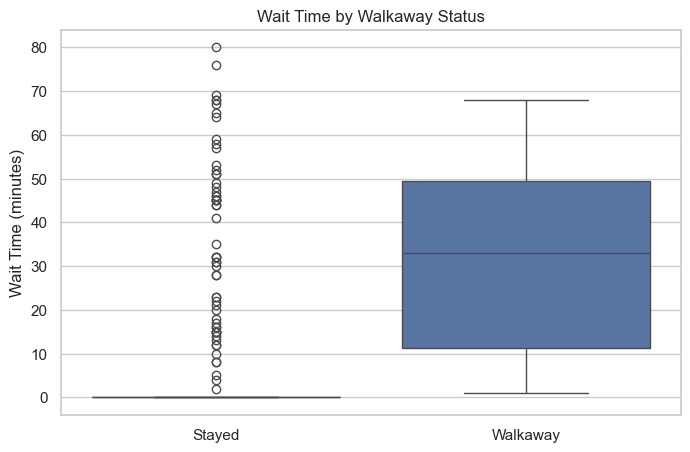

In [237]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="walkaway_label", y="wait_min")
plt.title("Wait Time by Walkaway Status")
plt.xlabel("")
plt.ylabel("Wait Time (minutes)")
plt.show()

ดูว่า In-house กับ Walk-in ใครรอนานกว่ากัน

In [238]:
df.groupby("guest_type")["wait_min"].agg(["count", "mean", "median", "min", "max"]).round(2)

,count,mean,median,min,max
guest_type,,,,,
In-House,157,4.46,0.0,0.0,69.0
Walk-In,207,8.91,0.0,0.0,80.0


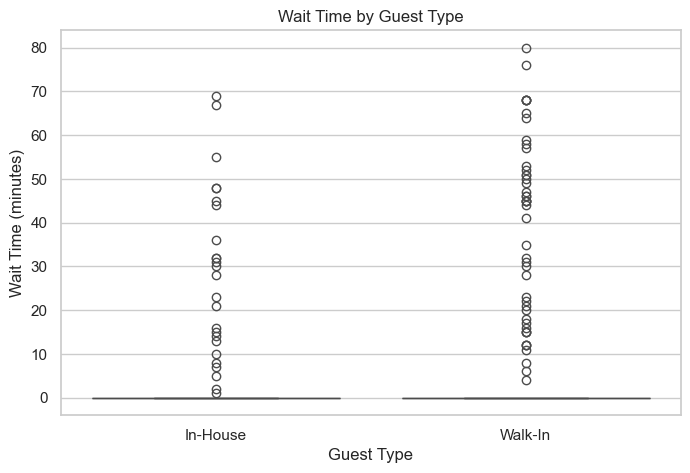

In [239]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="guest_type", y="wait_min")
plt.title("Wait Time by Guest Type")
plt.xlabel("Guest Type")
plt.ylabel("Wait Time (minutes)")
plt.show()

อันนี้ต้องดูว่ายุ่งทุกวันจริงไหม ไม่ใช่แค่บางวัน

ดูจำนวนกลุ่มลูกค้าต่อวัน

In [240]:
daily_groups = df.groupby("date")["service_no"].count().reset_index(name="groups")
daily_groups

,date,groups
0,2026-03-13,57
1,2026-03-14,81
2,2026-03-15,86
3,2026-03-17,70
4,2026-03-18,70


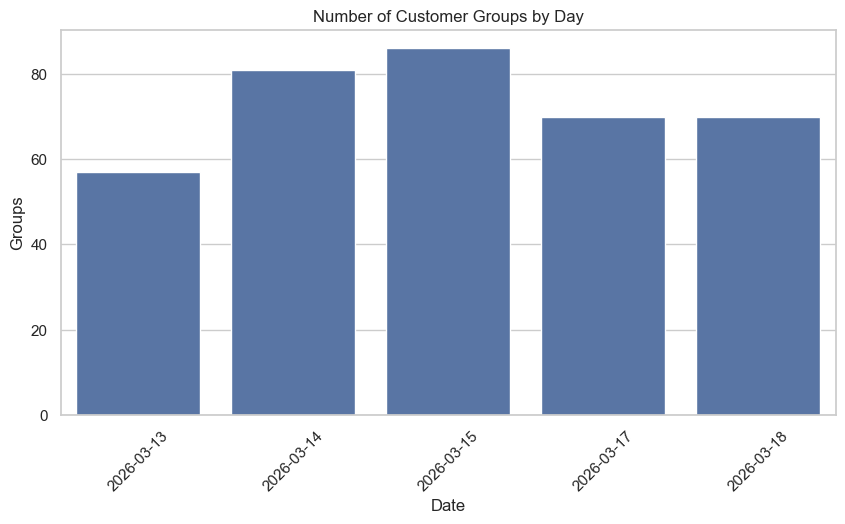

In [241]:
plt.figure(figsize=(10, 5))
sns.barplot(data=daily_groups, x="date", y="groups")
plt.title("Number of Customer Groups by Day")
plt.xlabel("Date")
plt.ylabel("Groups")
plt.xticks(rotation=45)
plt.show()

ดูจำนวนลูกค้ารวมต่อวัน

In [242]:
daily_pax = df.groupby("date")["party_size"].sum().reset_index(name="total_pax")
daily_pax

,date,total_pax
0,2026-03-13,102.0
1,2026-03-14,154.0
2,2026-03-15,166.0
3,2026-03-17,118.0
4,2026-03-18,122.0


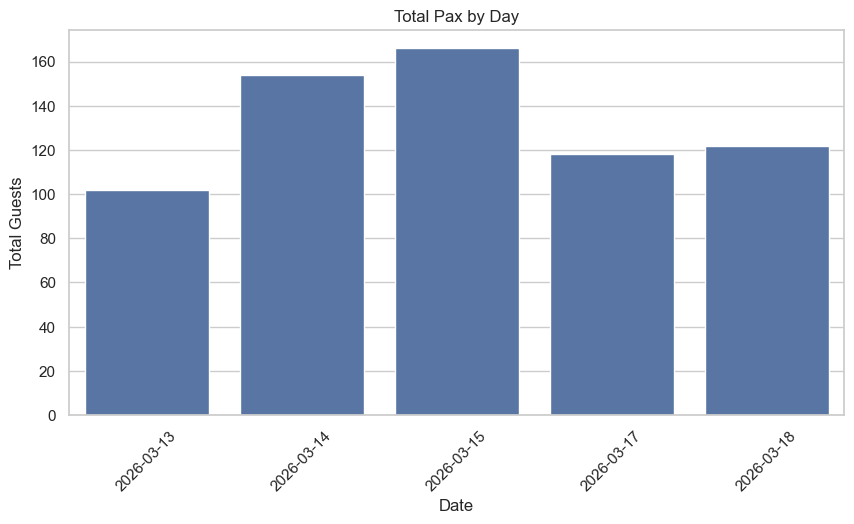

In [243]:
plt.figure(figsize=(10, 5))
sns.barplot(data=daily_pax, x="date", y="total_pax")
plt.title("Total Pax by Day")
plt.xlabel("Date")
plt.ylabel("Total Guests")
plt.xticks(rotation=45)
plt.show()

ดูรายได้โดยประมาณในแต่ละวัน

In [244]:
df["revenue"] = df["party_size"] * df["price"]

daily_revenue = df.groupby("date")["revenue"].sum().reset_index(name="total_revenue")
daily_revenue

,date,total_revenue
0,2026-03-13,16218.0
1,2026-03-14,30646.0
2,2026-03-15,33034.0
3,2026-03-17,18762.0
4,2026-03-18,19398.0


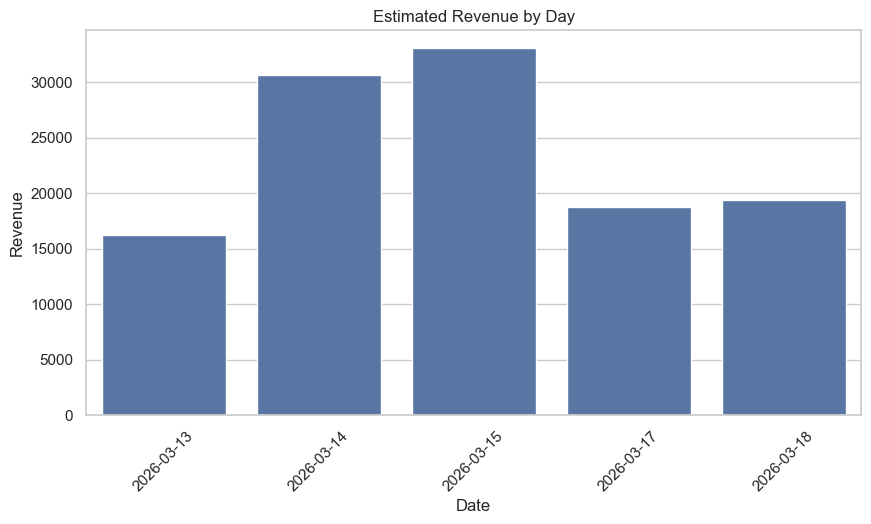

In [245]:
plt.figure(figsize=(10, 5))
sns.barplot(data=daily_revenue, x="date", y="total_revenue")
plt.title("Estimated Revenue by Day")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

เปรียบเทียบ weekday vs weekend

In [246]:
df.groupby("day_type").agg(
    groups=("service_no", "count"),
    total_pax=("party_size", "sum"),
    avg_wait=("wait_min", "mean"),
    walkaways=("is_walkaway", "sum"),
    revenue=("revenue", "sum")
).round(2)

,groups,total_pax,avg_wait,walkaways,revenue
day_type,,,,,
Weekday,197,342.0,0.00,0,54378.0
Weekend,167,320.0,15.23,14,63680.0


ดูว่าลูกค้าใช้เวลาในการทานนานแค่ไหน

“Walk-in นั่งทั้งวัน ทำให้ In-house ไม่มีที่นั่ง”


ภาพรวม meal duration

In [247]:
df["meal_min"].agg(["count", "mean", "median", "min", "max"]).round(2)

count     348.00
mean       61.23
median     52.00
min        10.00
max       321.00
Name: meal_min, dtype: float64

In [248]:
df.groupby("guest_type")["meal_min"].agg(["count", "mean", "median", "min", "max", "std"]).round(2)

,count,mean,median,min,max,std
guest_type,,,,,,
In-House,149,45.81,39.0,10.0,321.0,35.51
Walk-In,199,72.78,66.0,11.0,225.0,36.71


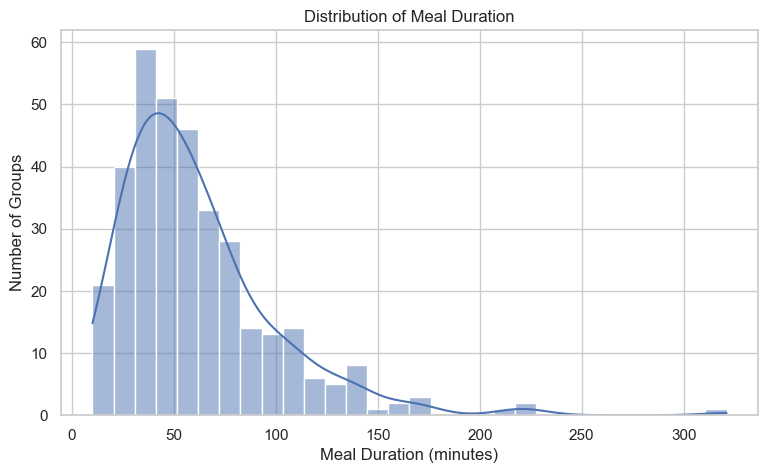

In [249]:
plt.figure(figsize=(9, 5))
sns.histplot(df["meal_min"].dropna(), bins=30, kde=True)
plt.title("Distribution of Meal Duration")
plt.xlabel("Meal Duration (minutes)")
plt.ylabel("Number of Groups")
plt.show()

เปรียบเทียบเวลาทานของ In-House กับ Walk-In

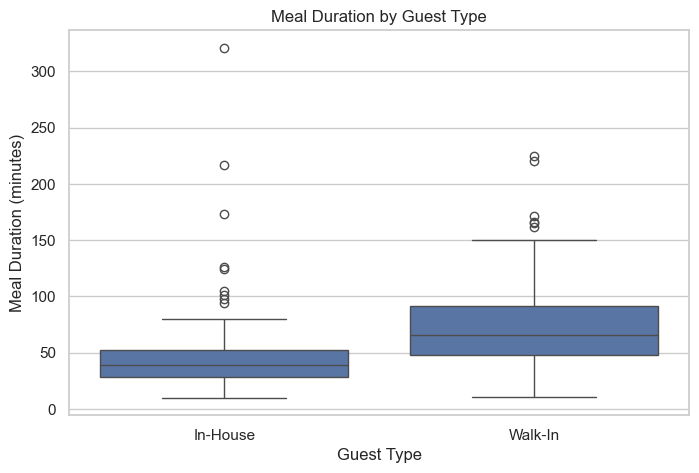

In [250]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="guest_type", y="meal_min")
plt.title("Meal Duration by Guest Type")
plt.xlabel("Guest Type")
plt.ylabel("Meal Duration (minutes)")
plt.show()

2. ดูสัดส่วนเวลาที่ส่วนใหญ่ลูกค้านั่งทาน

In [251]:
thresholds = [60, 90, 120, 180, 300]

for t in thresholds:
    pct = (df["meal_min"] > t).mean() * 100
    print(f"More than {t} min: {pct:.2f}%")

More than 60 min: 37.36%
More than 90 min: 16.48%
More than 120 min: 7.14%
More than 180 min: 1.10%
More than 300 min: 0.27%


ดูว่าเมื่อเวลาผ่านไป ลูกค้าสะสมกี่เปอร์เซ็นต์ที่ทานเสร็จแล้ว

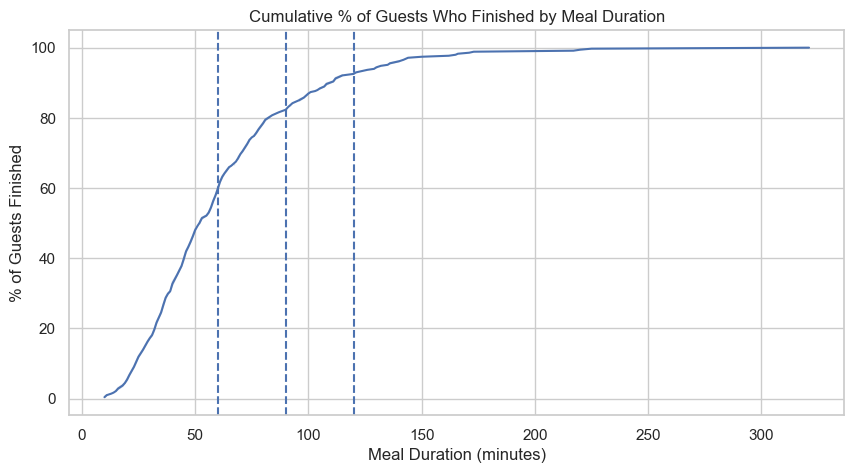

In [252]:
duration_df = df["meal_min"].dropna().sort_values().reset_index(drop=True)
cdf = pd.DataFrame({
    "meal_min": duration_df,
    "pct_left": np.arange(1, len(duration_df)+1) / len(duration_df) * 100
})

plt.figure(figsize=(10, 5))
sns.lineplot(data=cdf, x="meal_min", y="pct_left")
plt.axvline(60, linestyle="--")
plt.axvline(90, linestyle="--")
plt.axvline(120, linestyle="--")
plt.title("Cumulative % of Guests Who Finished by Meal Duration")
plt.xlabel("Meal Duration (minutes)")
plt.ylabel("% of Guests Finished")
plt.show()

ดูในเรื่องของราคา

In [253]:
df.groupby("day_type").agg(
    groups=("service_no", "count"),
    total_pax=("party_size", "sum"),
    avg_wait=("wait_min", "mean"),
    walkaways=("is_walkaway", "sum"),
    revenue=("revenue", "sum")
).round(2)

,groups,total_pax,avg_wait,walkaways,revenue
day_type,,,,,
Weekday,197,342.0,0.00,0,54378.0
Weekend,167,320.0,15.23,14,63680.0


2.2B จำลองรายได้หลาย scenario

In [254]:
current_pax = df["party_size"].sum()
current_revenue = df["revenue"].sum()

scenarios = pd.DataFrame({
    "scenario": ["Current", "259_no_drop", "259_drop_10%", "259_drop_20%", "259_drop_30%"],
    "estimated_revenue": [
        current_revenue,
        current_pax * 259,
        current_pax * 0.9 * 259,
        current_pax * 0.8 * 259,
        current_pax * 0.7 * 259
    ]
})

scenarios

,scenario,estimated_revenue
0,Current,118058.0
1,259_no_drop,171458.0
2,259_drop_10%,154312.2
3,259_drop_20%,137166.4
4,259_drop_30%,120020.6


ดูว่าถ้าขึ้นราคาจะคุ้มไหม

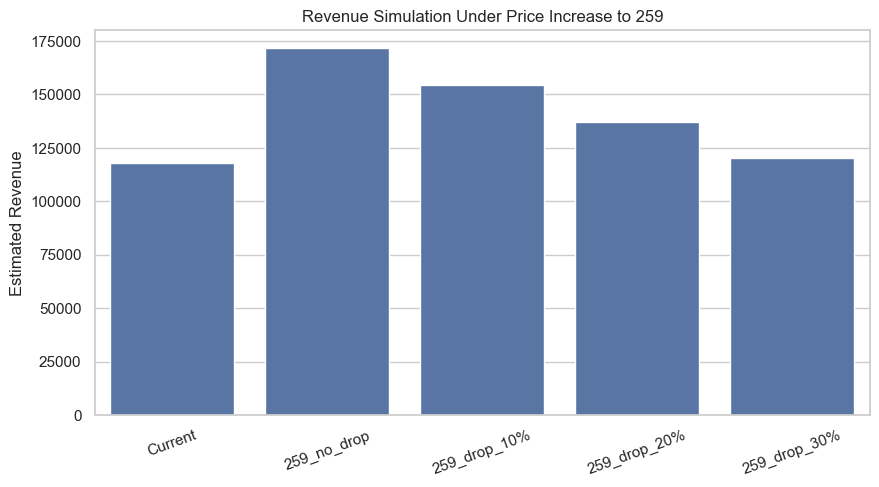

In [255]:
plt.figure(figsize=(10, 5))
sns.barplot(data=scenarios, x="scenario", y="estimated_revenue")
plt.title("Revenue Simulation Under Price Increase to 259")
plt.xlabel("")
plt.ylabel("Estimated Revenue")
plt.xticks(rotation=20)
plt.show()

ดูว่าคนที่ walkaway เป็นใคร

In [256]:
df.groupby("guest_type")["is_walkaway"].agg(["count", "sum", "mean"]).round(3)

,count,sum,mean
guest_type,,,
In-House,157,7,0.045
Walk-In,207,7,0.034


ดูการรอ ของ In-House vs Walk-In

In [257]:
df.groupby("guest_type")["wait_min"].agg(["mean", "median", "max"]).round(2)

,mean,median,max
guest_type,,,
In-House,4.46,0.0,69.0
Walk-In,8.91,0.0,80.0


ดูจำนวนลูกค้าแยกตามชั่วโมง และแยกประเภท In-House / Walk-In

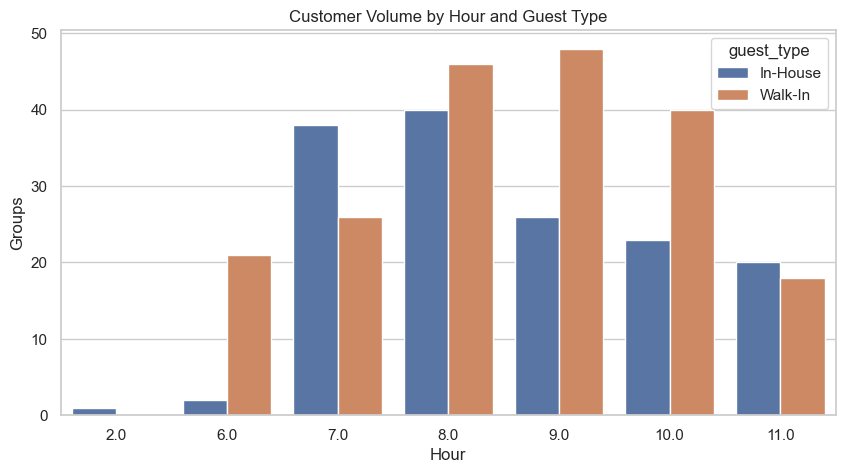

In [258]:
hour_guest = (
    df.groupby(["meal_hour", "guest_type"])
    .size()
    .reset_index(name="groups")
)

plt.figure(figsize=(10, 5))
sns.barplot(data=hour_guest, x="meal_hour", y="groups", hue="guest_type")
plt.title("Customer Volume by Hour and Guest Type")
plt.xlabel("Hour")
plt.ylabel("Groups")
plt.show()

ดูจำนวนกลุ่มลูกค้าในแต่ละชั่วโมงแบบรวมทั้งหมด

In [259]:
hourly_volume = (
    df["meal_hour"]
    .value_counts()
    .sort_index()
    .rename_axis("meal_hour")
    .reset_index(name="groups")
)

hourly_volume

,meal_hour,groups
0,2.0,1
1,6.0,23
2,7.0,64
3,8.0,86
4,9.0,74
5,10.0,63
6,11.0,38


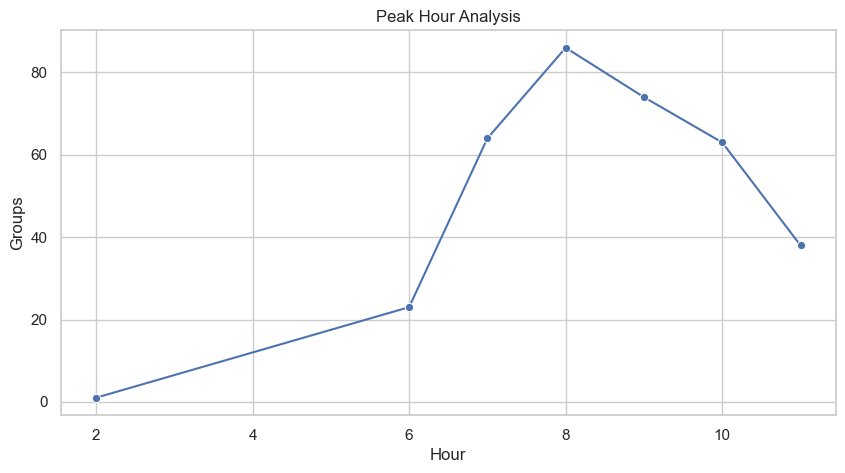

In [260]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_volume, x="meal_hour", y="groups", marker="o")
plt.title("Peak Hour Analysis")
plt.xlabel("Hour")
plt.ylabel("Groups")
plt.show()

ดูเฉพาะลูกค้า In-House ว่ามาเยอะช่วงไหน

In [261]:
inhouse_hour = (
    df[df["guest_type"] == "In-House"]["meal_hour"]
    .value_counts()
    .sort_index()
    .reset_index()
)
inhouse_hour.columns = ["meal_hour", "groups"]

inhouse_hour

,meal_hour,groups
0,2.0,1
1,6.0,2
2,7.0,38
3,8.0,40
4,9.0,26
5,10.0,23
6,11.0,20


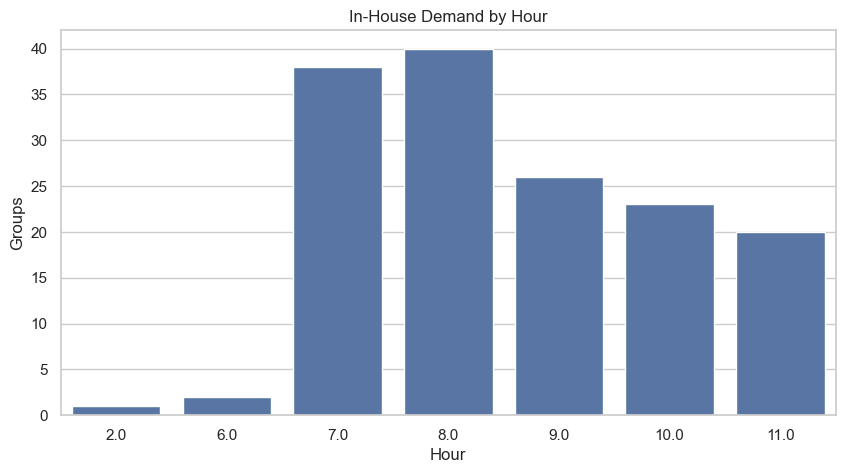

In [262]:
plt.figure(figsize=(10, 5))
sns.barplot(data=inhouse_hour, x="meal_hour", y="groups")
plt.title("In-House Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Groups")
plt.show()

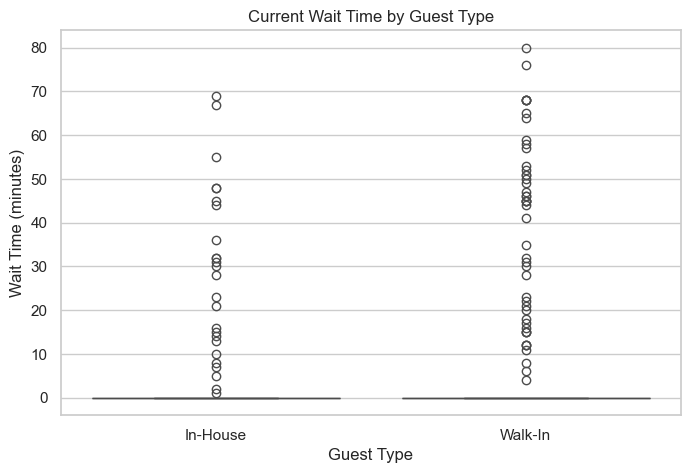

In [263]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="guest_type", y="wait_min")
plt.title("Current Wait Time by Guest Type")
plt.xlabel("Guest Type")
plt.ylabel("Wait Time (minutes)")
plt.show()

จำนวนกลุ่มลูกค้ารวมในแต่ละชั่วโมง โดยไม่แยกประเภท

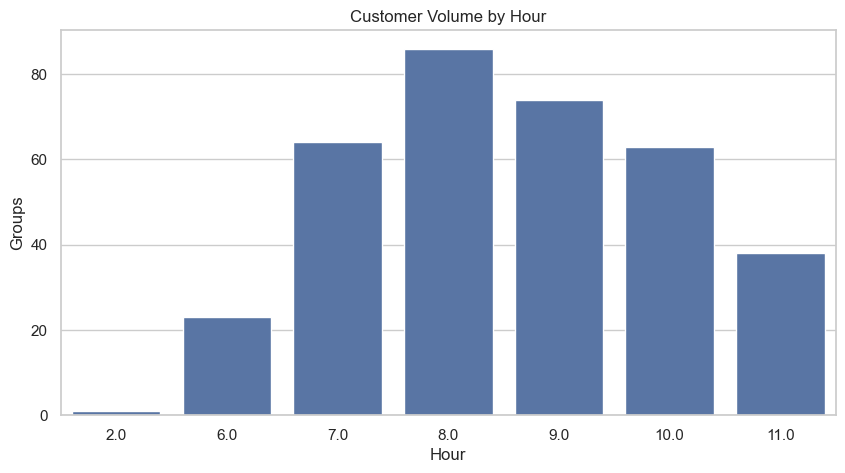

In [264]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="meal_hour")
plt.title("Customer Volume by Hour")
plt.xlabel("Hour")
plt.ylabel("Groups")
plt.show()

เปรียบเทียบเวลารอระหว่าง วันธรรมดา กับ วันหยุด

In [265]:
df.groupby("day_type").agg(
    groups=("service_no", "count"),
    avg_wait=("wait_min", "mean"),
    walkaways=("is_walkaway", "sum"),
    revenue=("revenue", "sum")
).round(2)

,groups,avg_wait,walkaways,revenue
day_type,,,,
Weekday,197,0.00,0,54378.0
Weekend,167,15.23,14,63680.0


ดูเวลารอวันธรรมดา vs วันหยุด

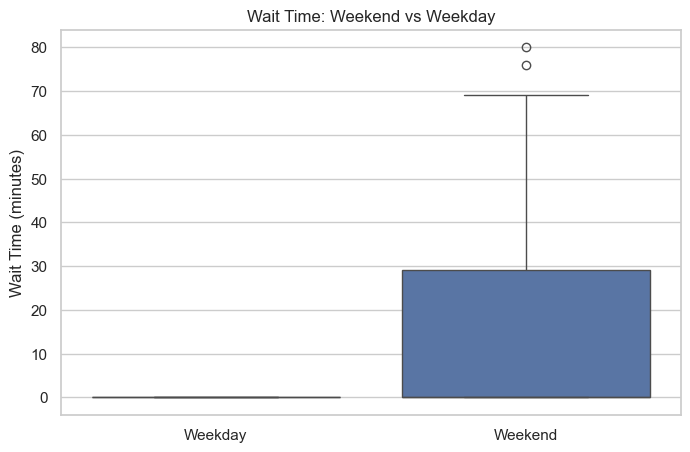

In [266]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="day_type", y="wait_min")
plt.title("Wait Time: Weekend vs Weekday")
plt.xlabel("")
plt.ylabel("Wait Time (minutes)")
plt.show()

1. KPI (หัว dashboard)

In [267]:
total_groups = df["service_no"].nunique()
total_pax = df["party_size"].sum()
walkaways = df["is_walkaway"].sum()
avg_wait = df["wait_min"].mean()
avg_meal = df["meal_min"].mean()

print(total_groups, total_pax, walkaways, avg_wait, avg_meal)

86 662.0 14 6.989010989010989 61.229885057471265


2. Peak Hour

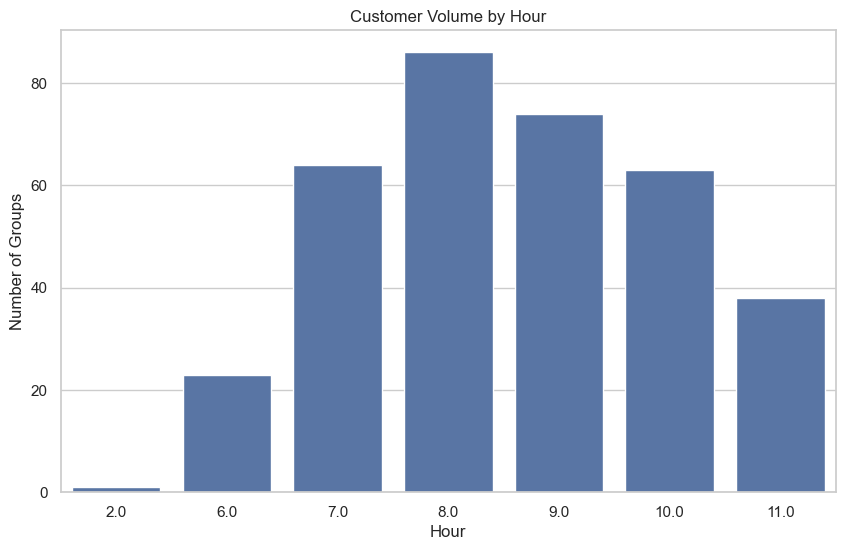

In [268]:
sns.countplot(data=df, x="meal_hour")
plt.title("Customer Volume by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Groups")
plt.show()

3. Average Wait by Guest Type (แทน box plot)
ดูเวลารอเฉลี่ย In-house vs Walk-in

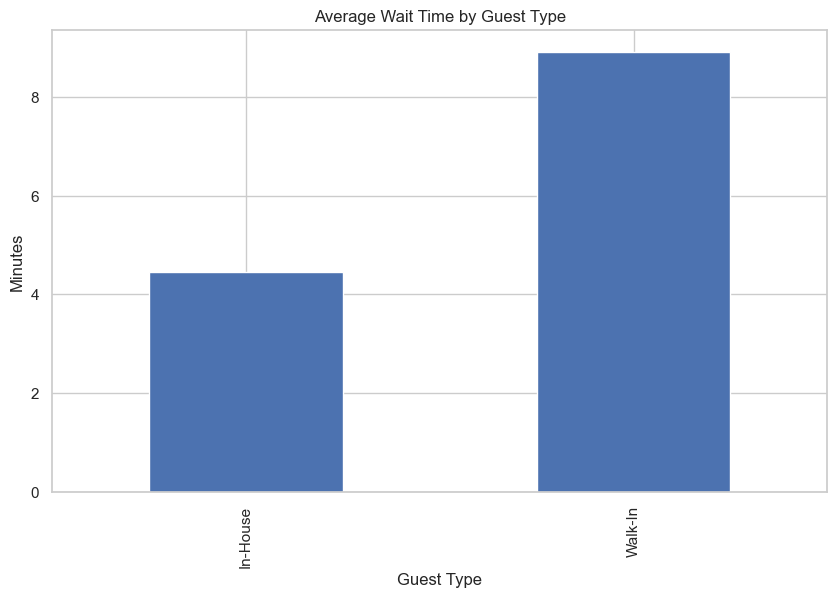

In [269]:
df.groupby("guest_type")["wait_min"].mean().plot(kind="bar")

plt.title("Average Wait Time by Guest Type")
plt.ylabel("Minutes")
plt.xlabel("Guest Type")
plt.show()

ดูสัดส่วนลูกค้า

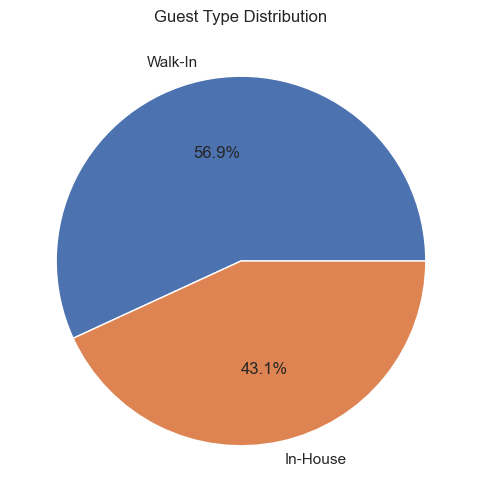

In [270]:
df["guest_type"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Guest Type Distribution")
plt.ylabel("")
plt.show()

ดูว่าใครเดินหนีมากกว่า

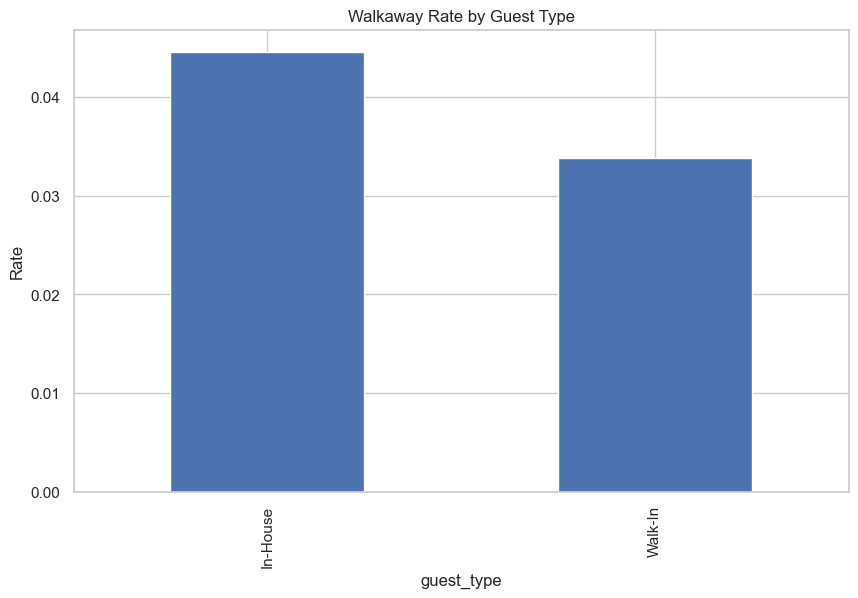

In [271]:
df.groupby("guest_type")["is_walkaway"].mean().plot(kind="bar")

plt.title("Walkaway Rate by Guest Type")
plt.ylabel("Rate")
plt.show()

ดูว่าลูกค้าเดินหนีกี่ %

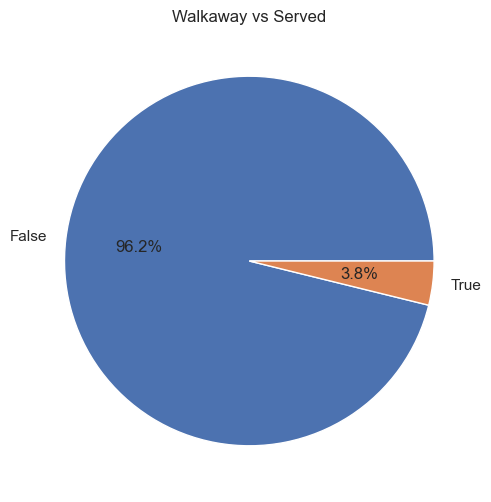

In [272]:
df["is_walkaway"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Walkaway vs Served")
plt.ylabel("")
plt.show()

ดูค่าเฉลี่ยเวลารอ

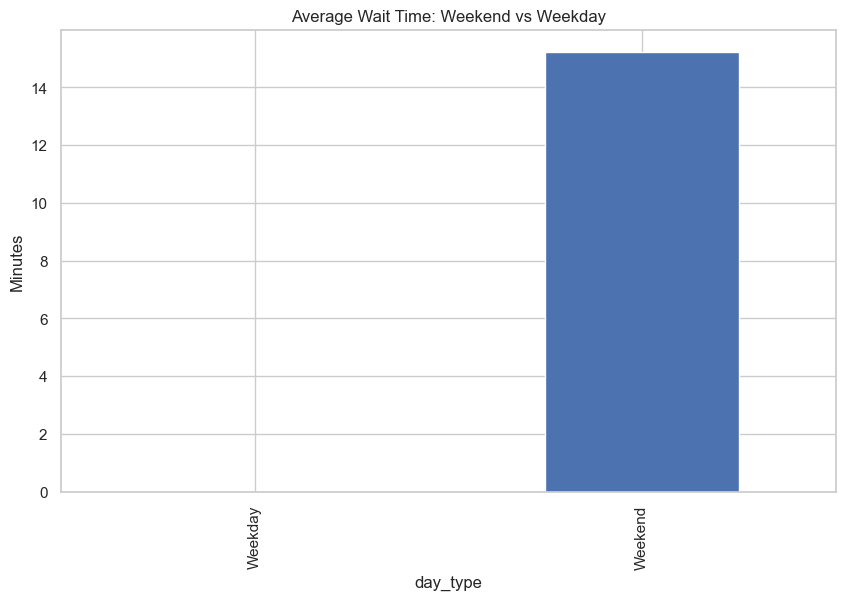

In [273]:
df.groupby("day_type")["wait_min"].mean().plot(kind="bar")

plt.title("Average Wait Time: Weekend vs Weekday")
plt.ylabel("Minutes")
plt.show()

ดูว่าส่วนใหญ่ลูกค้าทานกี่นาที

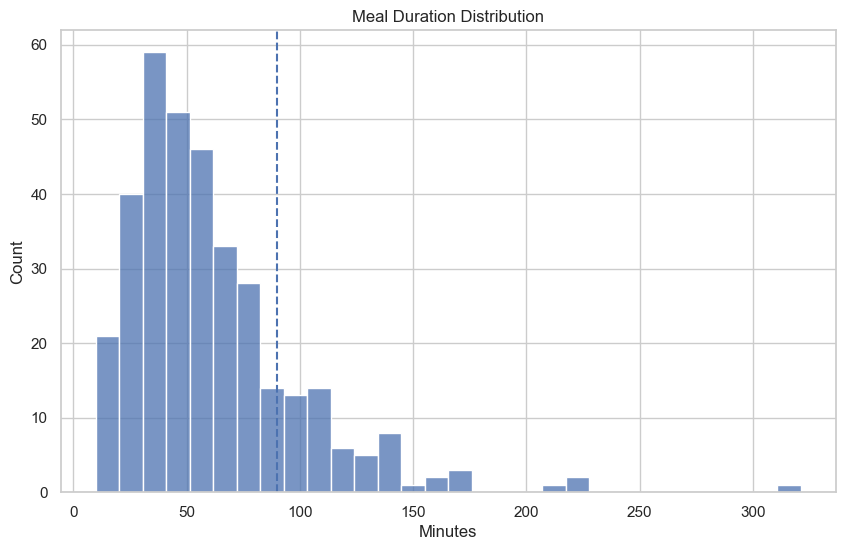

In [274]:
sns.histplot(df["meal_min"], bins=30)

plt.axvline(90, linestyle="--")
plt.title("Meal Duration Distribution")
plt.xlabel("Minutes")
plt.show()

ดูช่วงเวลาpeak + แยกประเภทลูกค้า

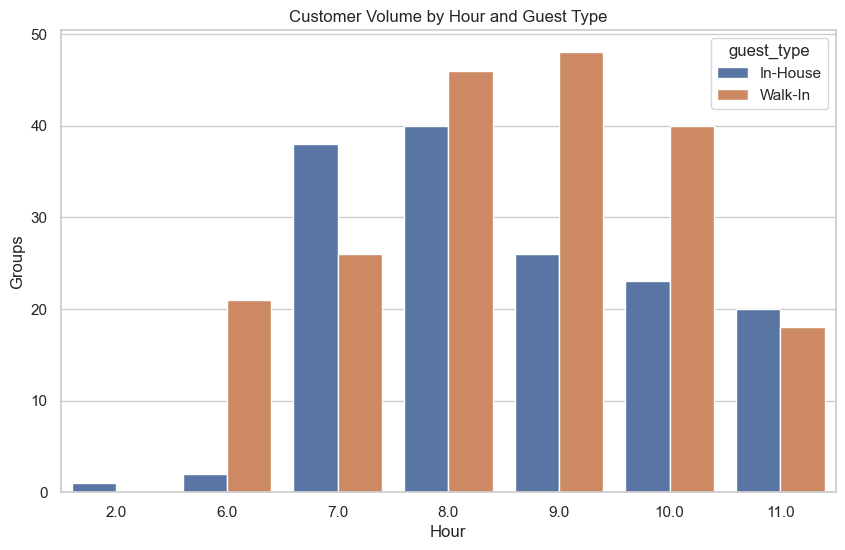

In [275]:
sns.countplot(data=df, x="meal_hour", hue="guest_type")

plt.title("Customer Volume by Hour and Guest Type")
plt.xlabel("Hour")
plt.ylabel("Groups")
plt.show()

จัดกลุ่มเวลาทาน

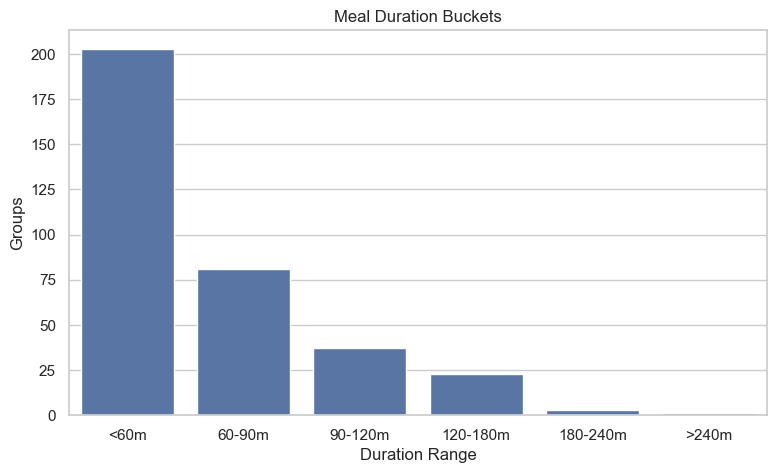

In [276]:
bins_labels = ['<60m', '60-90m', '90-120m', '120-180m', '180-240m', '>240m']
bins_vals = [0, 60, 90, 120, 180, 240, 1000]

meal_df = df[df['meal_min'].notna() & (df['meal_min'] > 0)].copy()
meal_df['dur_bin'] = pd.cut(meal_df['meal_min'], bins=bins_vals, labels=bins_labels, right=False)
bin_counts = meal_df['dur_bin'].value_counts().reindex(bins_labels, fill_value=0).reset_index()
bin_counts.columns = ['Duration', 'Groups']

plt.figure(figsize=(9, 5))
sns.barplot(data=bin_counts, x='Duration', y='Groups')
plt.title('Meal Duration Buckets')
plt.xlabel('Duration Range')
plt.ylabel('Groups')
plt.show()

ดูรายได้ weekday vs weekend

c:\Users\Acer\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


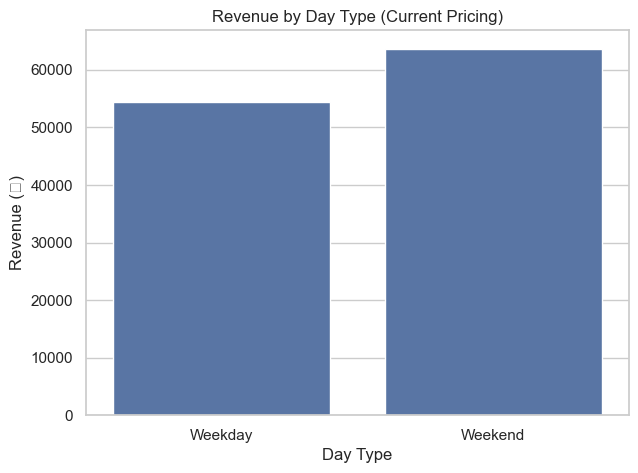

In [277]:
df['revenue'] = df['party_size'] * df['price']
rev_daytype = df.groupby('day_type', as_index=False)['revenue'].sum()

plt.figure(figsize=(7, 5))
sns.barplot(data=rev_daytype, x='day_type', y='revenue')
plt.title('Revenue by Day Type (Current Pricing)')
plt.xlabel('Day Type')
plt.ylabel('Revenue (฿)')
plt.show()

ดูว่า In-house ต้องรอไหม

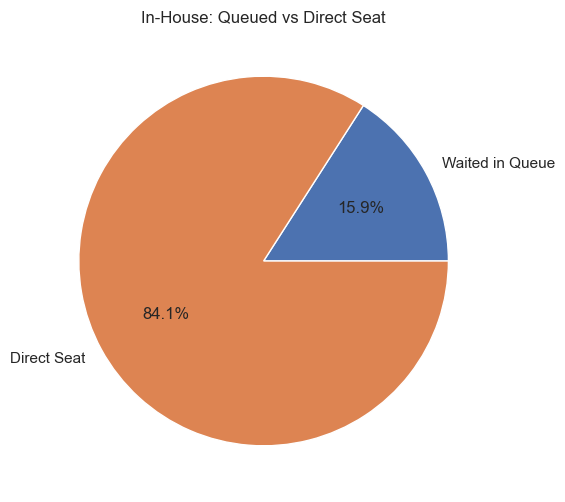

In [278]:
ih_df = df[df['guest_type'] == 'In-House']
waited = ih_df['had_queue'].sum()
direct = (~ih_df['had_queue']).sum()

plt.figure(figsize=(6, 6))
plt.pie(
    [waited, direct],
    labels=['Waited in Queue', 'Direct Seat'],
    autopct='%1.1f%%',
)
plt.title('In-House: Queued vs Direct Seat')
plt.show()

ดูว่า In-house มาเวลาไหน

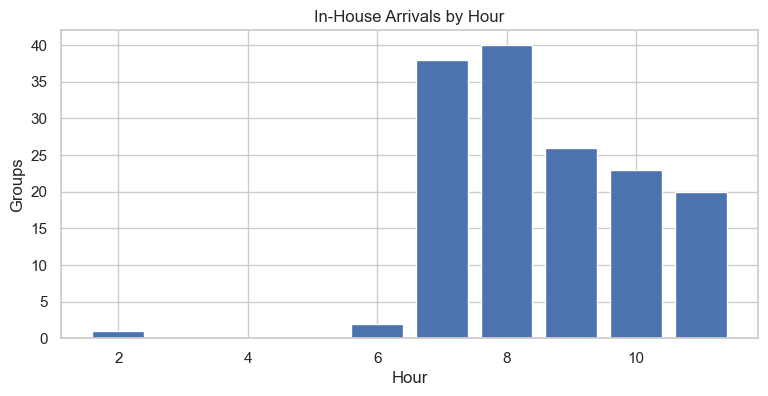

In [279]:
total_tables = 20
turnover = 2.5

ih_hourly = (
    df[df['guest_type'] == 'In-House']
    .groupby('meal_hour')
    .size()
    .reset_index(name='groups')
)

# กราฟ 1: In-House arrivals by hour — highlight ช่วง peak
ih_hourly['is_peak'] = ih_hourly['meal_hour'].between(7, 10)


plt.figure(figsize=(9, 4))
plt.bar(ih_hourly['meal_hour'], ih_hourly['groups'])
plt.title('In-House Arrivals by Hour')
plt.xlabel('Hour')
plt.ylabel('Groups')
plt.show()


ดูว่า ช่วงที่ลูกค้าเข้ามาเยอะที่สุด เทียบกับ โต๊ะที่เตรียมไว้จะพอไหม

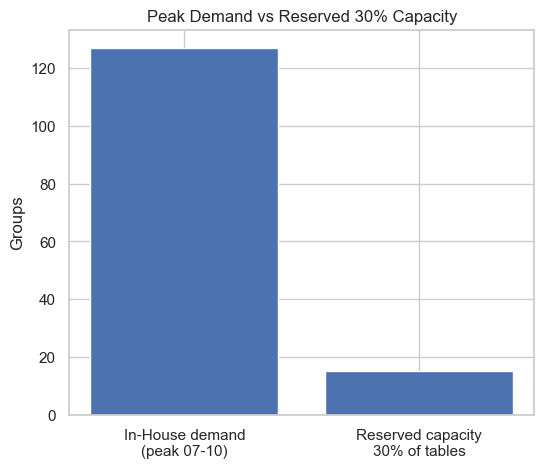

In [280]:
peak_groups = ih_hourly[ih_hourly['is_peak']]['groups'].sum()
reserve_cap = 0.30 * total_tables * turnover

plt.figure(figsize=(6, 5))
plt.bar(
    ['In-House demand\n(peak 07-10)', 'Reserved capacity\n30% of tables'],
    [peak_groups, reserve_cap]
)
plt.title('Peak Demand vs Reserved 30% Capacity')
plt.ylabel('Groups')
plt.show()